# 🔬 Fine-Tuning para Detecção de Code Smells — Treinos Separados

**Modelo:** CodeBERT (`microsoft/codebert-base`)  
**Datasets:** `DataClassSmelly.csv` e `FeatureEnvySmelly.csv` — treinados **separadamente**  
**Tarefa:** Classificação Binária — *Code Smell* (1) vs *Código Normal* (0)  
**Divisão:** 80% treino / 20% teste (estratificada)

---
### 🗺️ Mapa de Experimentos
| Experimento | Modelo    | Dataset       |
|-------------|-----------|---------------|
| EXP-1       | CodeBERT  | Data Class    |
| EXP-2       | CodeBERT  | Feature Envy  |

## 1. Instalação de Dependências

In [1]:
%%capture
!pip install transformers==4.40.0 datasets scikit-learn pandas numpy matplotlib seaborn torch accelerate -q

## 2. Importações

In [2]:
import os, re, json, random, warnings, copy
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, classification_report, roc_curve,
)

# ── Detecção de GPUs ──────────────────────────────────────────
N_GPUS = torch.cuda.device_count()
print(f'✅ Imports OK')
print(f'🔥 PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()} | GPUs: {N_GPUS}')
for i in range(N_GPUS):
    print(f'   GPU {i}: {torch.cuda.get_device_name(i)}')


✅ Imports OK
🔥 PyTorch 2.10.0+cu128 | CUDA: True | GPUs: 2
   GPU 0: Tesla T4
   GPU 1: Tesla T4


## 3. Configurações Globais

In [ ]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()

# ── Número de GPUs disponíveis ────────────────────────────────
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 1
_BATCH_PER_GPU = 8

CONFIG = {
    # ── Caminhos ──────────────────────────────────────────
    'data_class_path'   : '/kaggle/input/datasets/rafaelstc/smelly-codesmellsdataset/DataClassSmelly.csv',
    'feature_envy_path' : '/kaggle/input/datasets/rafaelstc/smelly-codesmellsdataset/FeatureEnvySmelly.csv',
    'output_dir'        : '/kaggle/working/',

    # ── Dados ─────────────────────────────────────────────
    'test_size'         : 0.20,
    'max_length'        : 512,

    # ── Treino ────────────────────────────────────────────
    'batch_size'        : _BATCH_PER_GPU * N_GPUS,
    'num_epochs'        : 3,
    'learning_rate'     : 1e-5 * N_GPUS,
    'weight_decay'      : 0.01,
    'warmup_ratio'      : 0.04,
    'grad_clip'         : 1.0,
    'log_steps'         : 100,

    # ── Modelos ───────────────────────────────────────────
    'codebert_name'     : 'microsoft/codebert-base',
    'num_labels'        : 2,
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EXP_COLORS = {
    'CodeBERT × Data Class'   : '#1565C0',
    'CodeBERT × Feature Envy' : '#42A5F5',
}

n_train_dc = int(70000 * (1 - CONFIG['test_size']))
n_train_fe = int(30000 * (1 - CONFIG['test_size']))
for ds, n in [('Data Class (70k)', n_train_dc), ('Feature Envy (30k)', n_train_fe)]:
    steps = (n // CONFIG['batch_size']) * CONFIG['num_epochs']
    print(f'  {ds}: ~{steps:,} steps totais por modelo')

print(f'\n Dispositivo   : {DEVICE}')
print(f' GPUs ativas   : {N_GPUS}')
print(f' batch_size    : {CONFIG["batch_size"]} ({_BATCH_PER_GPU}/GPU × {N_GPUS} GPU(s))')
print(f' learning_rate : {CONFIG["learning_rate"]:.2e}')
print(f' max_length    : {CONFIG["max_length"]}  |  epochs: {CONFIG["num_epochs"]}')
print(f' log_steps     : {CONFIG["log_steps"]}')


  Data Class (70k): ~10,500 steps totais por modelo
  Feature Envy (30k): ~4,500 steps totais por modelo

 Dispositivo   : cuda
 GPUs ativas   : 2
 batch_size    : 16 (8/GPU × 2 GPU(s))
 learning_rate : 2.00e-05
 max_length    : 512  |  epochs: 3
 log_steps     : 100


## 4. Carregamento

In [4]:
def load_and_clean(path: str, smell_type: str) -> pd.DataFrame:
    for encoding in ('utf-8', 'latin-1', 'cp1252', 'utf-8-sig'):
        try:
            df = pd.read_csv(
                path,
                sep          = ';',
                engine       = 'python',
                quotechar    = '"',
                on_bad_lines = 'skip',
                encoding     = encoding,
            )
            print(f'  [{smell_type}] encoding={encoding} | shape={df.shape}')
            print(f'  [{smell_type}] colunas: {list(df.columns)}')
            break
        except UnicodeDecodeError:
            continue
    else:
        raise RuntimeError(f'Nao foi possivel ler {path}')

    df.columns = df.columns.str.strip().str.lower()

    col_map = {}
    for col in df.columns:
        if col in ('method', 'method_body', 'methodbody', 'code', 'source', 'sourcecode', 'method_code'):
            col_map[col] = 'method'
        elif col in ('severity', 'label', 'class', 'smell', 'is_smell', 'target', 'output'):
            col_map[col] = 'severity'
    df.rename(columns=col_map, inplace=True)

    assert 'method' in df.columns, (
        f"Coluna de codigo nao encontrada.\n"
        f"Colunas disponiveis: {list(df.columns)}\n"
        f"Adicione o nome correto no col_map acima."
    )
    assert 'severity' in df.columns, (
        f"Coluna de rotulo nao encontrada.\n"
        f"Colunas disponiveis: {list(df.columns)}\n"
        f"Adicione o nome correto no col_map acima."
    )

    df.dropna(subset=['method', 'severity'], inplace=True)
    df['severity']   = df['severity'].astype(int)
    df['method']     = df['method'].astype(str).str.strip()
    df['smell_type'] = smell_type
    df = df[df['method'].str.len() > 0].reset_index(drop=True)
    return df

df_dc = load_and_clean(CONFIG['data_class_path'],   'data_class')
df_fe = load_and_clean(CONFIG['feature_envy_path'], 'feature_envy')

DATASETS = {
    'Data Class'   : df_dc,
    'Feature Envy' : df_fe,
}

print('═' * 52)
for name, df in DATASETS.items():
    n0 = (df['severity']==0).sum()
    n1 = (df['severity']==1).sum()
    print(f'  {name:<14}: {len(df):>6,} exemplos  |  Normal={n0:,}  Smell={n1:,}')
print('═' * 52)


  [data_class] encoding=latin-1 | shape=(71412, 3)
  [data_class] colunas: ['sample_id', 'severity', 'method']
  [feature_envy] encoding=utf-8 | shape=(33366, 3)
  [feature_envy] colunas: ['sample_id', 'severity', 'method']
════════════════════════════════════════════════════
  Data Class    : 71,412 exemplos  |  Normal=68,095  Smell=3,317
  Feature Envy  : 33,366 exemplos  |  Normal=31,350  Smell=2,016
════════════════════════════════════════════════════


## 5. Utilitários — Dataset, Treino e Avaliação

In [5]:
# ── Pré-processamento ─────────────────────────────────────────
def preprocess_code(code: str) -> str:
    code = re.sub(r'/\*.*?\*/', ' ', code, flags=re.DOTALL)
    code = re.sub(r'//[^\n]*', ' ', code)
    code = re.sub(r'\s+', ' ', code)
    return code.strip()


# ── Dataset PyTorch ───────────────────────────────────────────
class CodeSmellDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts), truncation=True,
            padding='max_length', max_length=max_length,
            return_tensors='pt',
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


# ── Divisão de dados ─────────────────────────────────────────
def split_dataset(df: pd.DataFrame):
    df = df.copy()
    df['method_clean'] = df['method'].apply(preprocess_code)
    X, y = df['method_clean'].values, df['severity'].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=CONFIG['test_size'],
        random_state=SEED, stratify=y
    )
    print(f'   Treino: {len(X_tr):,}  (Normal={sum(y_tr==0):,} | Smell={sum(y_tr==1):,})')
    print(f'   Teste : {len(X_te):,}  (Normal={sum(y_te==0):,} | Smell={sum(y_te==1):,})')
    return X_tr, X_te, y_tr, y_te


# ── Métricas ─────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob=None):
    m = {
        'accuracy'         : accuracy_score(y_true, y_pred),
        # Métricas focadas na classe Smell (pos_label=1)
        'precision_smell'  : precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_smell'     : recall_score(y_true, y_pred,    pos_label=1, zero_division=0),
        'f1_smell'         : f1_score(y_true, y_pred,        pos_label=1, zero_division=0),
        # Métricas globais para referência e comparação com literatura
        'f1_macro'         : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_weighted'      : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'mcc'              : matthews_corrcoef(y_true, y_pred),
    }
    if y_prob is not None:
        try:    m['roc_auc'] = roc_auc_score(y_true, y_prob)
        except: m['roc_auc'] = float('nan')
    return m


# ── Utilitário: extrai o modelo base de dentro do DataParallel ──
def unwrap(model):
    """Retorna o módulo interno se embrulhado em DataParallel."""
    return model.module if isinstance(model, nn.DataParallel) else model


# ── Loop de treino com suporte a multi-GPU (DataParallel) ─────
def train_model(model, train_loader, val_loader, exp_label, y_train):
    """
    Treina o modelo com DataParallel quando mais de 1 GPU está disponível.
    DataParallel divide o batch entre as GPUs a cada forward pass e
    agrega os gradientes automaticamente — zero mudança na lógica de treino.
    """
    use_dp = N_GPUS > 1
    if use_dp:
        print(f'  🖥️  Usando {N_GPUS} GPUs com DataParallel')
        model = nn.DataParallel(model)
    model.to(DEVICE)

    # ── Class weights para desbalanceamento ──────────────────
    counts  = np.bincount(y_train)
    weights = torch.tensor(len(y_train) / (2 * counts), dtype=torch.float).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss(weight=weights)
    print(f'  ⚖️  Class weights: Normal={weights[0]:.3f} | Smell={weights[1]:.3f}')

    # Otimizador aplicado aos parâmetros do modelo (embrulhado ou não)
    optimizer = AdamW(model.parameters(),
                      lr=CONFIG['learning_rate'],
                      weight_decay=CONFIG['weight_decay'])
    total_steps  = len(train_loader) * CONFIG['num_epochs']
    warmup_steps = int(total_steps * CONFIG['warmup_ratio'])
    scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_f1_smell': []}
    best_f1, best_state = 0.0, None

    for epoch in range(CONFIG['num_epochs']):
        # ── Treino ───────────────────────────────────────────
        model.train()
        total_tr_loss = 0
        for step, batch in enumerate(train_loader):
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            # DataParallel pode retornar logits concatenados; pegamos sempre .logits
            logits  = outputs.logits if hasattr(outputs, 'logits') else outputs[1]
            loss    = loss_fn(logits, batch['labels'])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
            total_tr_loss += loss.item()
            if (step + 1) % CONFIG['log_steps'] == 0:
                print(f'  [{exp_label}] Ep {epoch+1} | Step {step+1}/{len(train_loader)} '
                      f'| Loss {total_tr_loss/(step+1):.4f}')

        avg_tr = total_tr_loss / len(train_loader)

        # ── Validação ────────────────────────────────────────
        model.eval()
        total_val_loss = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch   = {k: v.to(DEVICE) for k, v in batch.items()}
                outputs = model(**batch)
                logits  = outputs.logits if hasattr(outputs, 'logits') else outputs[1]
                total_val_loss += loss_fn(logits, batch['labels']).item()
                preds  = torch.argmax(logits, dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(batch['labels'].cpu().numpy())

        avg_val = total_val_loss / len(val_loader)
        val_f1  = f1_score(all_labels, all_preds, zero_division=0)
        val_f1_smell = f1_score(all_labels, all_preds, pos_label=1, zero_division=0)
        val_recall   = recall_score(all_labels, all_preds, pos_label=1, zero_division=0)

        history['train_loss'].append(avg_tr)
        history['val_loss'].append(avg_val)
        history['val_f1'].append(val_f1)
        history['val_f1_smell'].append(val_f1_smell)

        star = ''
        # Checkpoint baseado em F1 da classe Smell
        if val_f1_smell > best_f1:
            best_f1    = val_f1_smell
            best_state = {k: v.cpu().clone() for k, v in unwrap(model).state_dict().items()}
            star = '  ✨ melhor F1-Smell!'

        print(f'  [{exp_label}] Ep {epoch+1}/{CONFIG["num_epochs"]} '
              f'| TrLoss {avg_tr:.4f} | ValLoss {avg_val:.4f} '
              f'| F1-Smell {val_f1_smell:.4f} | Recall-Smell {val_recall:.4f}{star}')

    # Restaura os melhores pesos no módulo interno
    if best_state:
        unwrap(model).load_state_dict(best_state)
    print(f'✅ [{exp_label}] Concluído — melhor ValF1: {best_f1:.4f}\n')
    return model, history


# ── Avaliação no conjunto de teste ───────────────────────────
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            logits  = outputs.logits if hasattr(outputs, 'logits') else outputs[1]
            probs   = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            preds   = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].cpu().numpy())
            all_probs.extend(probs)
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


# ── Painel de resultados individuais ─────────────────────────
def plot_experiment(history, y_true, y_pred, y_prob, exp_label, color, save_path):
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f'📊 Resultados — {exp_label}', fontsize=14, fontweight='bold')
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, 0])
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], 'o-', color=color, linewidth=2, label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   's--', color=color, alpha=0.5, linewidth=2, label='Val Loss')
    ax1_r = ax1.twinx()
    ax1_r.plot(epochs, history['val_f1'],       '^:', color='green',  linewidth=2, label='Val F1 Global')
    ax1_r.plot(epochs, history['val_f1_smell'], 's-', color='purple', linewidth=2, label='Val F1 Smell ★')
    ax1_r.set_ylabel('F1', color='green')
    ax1_r.tick_params(axis='y', labelcolor='green')
    lines1, lbl1 = ax1.get_legend_handles_labels()
    lines2, lbl2 = ax1_r.get_legend_handles_labels()
    ax1.legend(lines1+lines2, lbl1+lbl2, fontsize=8, loc='upper right')
    ax1.set_title('Curva de Treino', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 1])
    cm      = confusion_matrix(y_true, y_pred)
    cm_pct  = cm.astype(float) / cm.sum(axis=1)[:,np.newaxis] * 100
    annot   = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)' for j in range(2)] for i in range(2)])
    cmap    = plt.cm.Blues if 'CodeBERT' in exp_label else plt.cm.Oranges
    sns.heatmap(cm, annot=annot, fmt='', ax=ax2, cmap=cmap,
                xticklabels=['Normal','Smell'], yticklabels=['Normal','Smell'],
                linewidths=0.5, cbar=False, annot_kws={'size':11,'weight':'bold'})
    ax2.set_title('Matriz de Confusão', fontweight='bold')
    ax2.set_xlabel('Predito'); ax2.set_ylabel('Real')

    ax3 = fig.add_subplot(gs[0, 2])
    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val     = roc_auc_score(y_true, y_prob)
        ax3.plot(fpr, tpr, color=color, linewidth=2.5, label=f'AUC = {auc_val:.3f}')
    except Exception:
        pass
    ax3.plot([0,1],[0,1],'k--', linewidth=1)
    ax3.set_title('Curva ROC', fontweight='bold')
    ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
    ax3.legend(); ax3.grid(True, alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 0])
    ax4.hist(y_prob[y_true==0], bins=30, alpha=0.6, color='#4CAF50', label='Normal (real)')
    ax4.hist(y_prob[y_true==1], bins=30, alpha=0.6, color='#F44336', label='Smell (real)')
    ax4.axvline(0.5, color='black', linestyle='--', linewidth=1.5)
    ax4.set_title('Distribuição das Probabilidades', fontweight='bold')
    ax4.set_xlabel('P(Smell)'); ax4.legend(fontsize=8)

    ax5 = fig.add_subplot(gs[1, 1])
    metrics = compute_metrics(y_true, y_pred, y_prob)
    met_keys = ['accuracy','precision_smell','recall_smell','f1_smell','f1_macro','mcc']
    met_lbls = ['Accuracy','Precision Smell','Recall Smell','F1 Smell ★','F1 Macro','MCC']
    vals = [metrics[k] for k in met_keys]
    bars = ax5.barh(met_lbls, vals, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax5.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9)
    ax5.set_xlim(0, 1.15)
    ax5.set_title('Métricas de Classificação', fontweight='bold')
    ax5.grid(axis='x', alpha=0.3)

    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis('off')
    report = classification_report(y_true, y_pred,
                                   target_names=['Normal','Smell'],
                                   output_dict=True)
    rows = []
    for cls in ['Normal','Smell','macro avg','weighted avg']:
        r = report.get(cls, {})
        rows.append([cls,
                     f"{r.get('precision',0):.3f}",
                     f"{r.get('recall',0):.3f}",
                     f"{r.get('f1-score',0):.3f}",
                     f"{int(r.get('support',0))}"])
    tbl = ax6.table(cellText=rows,
                    colLabels=['Classe','Prec','Rec','F1','Support'],
                    cellLoc='center', loc='center',
                    bbox=[0.0, 0.1, 1.0, 0.85])
    tbl.auto_set_font_size(False); tbl.set_fontsize(10)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#37474F')
            cell.set_text_props(color='white', fontweight='bold')
        elif row % 2 == 0:
            cell.set_facecolor('#ECEFF1')
    ax6.set_title('Classification Report', fontweight='bold')

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Painel salvo em {save_path}')
    return metrics


print('✅ Todos os utilitários definidos!')
print(f'   DataParallel será ativado: {N_GPUS > 1} ({N_GPUS} GPU(s))')


✅ Todos os utilitários definidos!
   DataParallel será ativado: True (2 GPU(s))


---
## 6. EXP-1 — CodeBERT × Data Class

In [ ]:
print('═'*55)
print('  🔵 EXP-1 — CodeBERT × Data Class')
print('═'*55)

X_tr, X_te, y_tr, y_te = split_dataset(df_dc)

tok_cb = RobertaTokenizer.from_pretrained(CONFIG['codebert_name'])

train_ds = CodeSmellDataset(X_tr, y_tr, tok_cb, CONFIG['max_length'])
test_ds  = CodeSmellDataset(X_te, y_te, tok_cb, CONFIG['max_length'])

_nw = min(2 * N_GPUS, 4)
train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
                      num_workers=_nw, pin_memory=True, persistent_workers=True)
test_dl  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False,
                      num_workers=_nw, pin_memory=True, persistent_workers=True)

model_cb_dc = RobertaForSequenceClassification.from_pretrained(
    CONFIG['codebert_name'], num_labels=CONFIG['num_labels'])

model_cb_dc, hist_cb_dc = train_model(model_cb_dc, train_dl, test_dl, 'CodeBERT×DataClass', y_tr)


═══════════════════════════════════════════════════════
  🔵 EXP-1 — CodeBERT × Data Class
═══════════════════════════════════════════════════════
   Treino: 57,129  (Normal=54,475 | Smell=2,654)
   Teste : 14,283  (Normal=13,620 | Smell=663)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  🖥️  Usando 2 GPUs com DataParallel
  ⚖️  Class weights: Normal=0.524 | Smell=10.763


2026-06-10 23:00:41.403968: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781132441.643517      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781132441.711724      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781132442.249110      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781132442.249166      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781132442.249169      57 computation_placer.cc:177] computation placer alr

  [CodeBERT×DataClass] Ep 1 | Step 100/3571 | Loss 0.6268
  [CodeBERT×DataClass] Ep 1 | Step 200/3571 | Loss 0.5915
  [CodeBERT×DataClass] Ep 1 | Step 300/3571 | Loss 0.6108
  [CodeBERT×DataClass] Ep 1 | Step 400/3571 | Loss 0.6283
  [CodeBERT×DataClass] Ep 1 | Step 500/3571 | Loss 0.6249
  [CodeBERT×DataClass] Ep 1 | Step 600/3571 | Loss 0.6250
  [CodeBERT×DataClass] Ep 1 | Step 700/3571 | Loss 0.5999
  [CodeBERT×DataClass] Ep 1 | Step 800/3571 | Loss 0.5904
  [CodeBERT×DataClass] Ep 1 | Step 900/3571 | Loss 0.5780
  [CodeBERT×DataClass] Ep 1 | Step 1000/3571 | Loss 0.5572
  [CodeBERT×DataClass] Ep 1 | Step 1100/3571 | Loss 0.5437
  [CodeBERT×DataClass] Ep 1 | Step 1200/3571 | Loss 0.5383
  [CodeBERT×DataClass] Ep 1 | Step 1300/3571 | Loss 0.5200
  [CodeBERT×DataClass] Ep 1 | Step 1400/3571 | Loss 0.5255
  [CodeBERT×DataClass] Ep 1 | Step 1500/3571 | Loss 0.5195
  [CodeBERT×DataClass] Ep 1 | Step 1600/3571 | Loss 0.5086
  [CodeBERT×DataClass] Ep 1 | Step 1700/3571 | Loss 0.4990
  [Cod

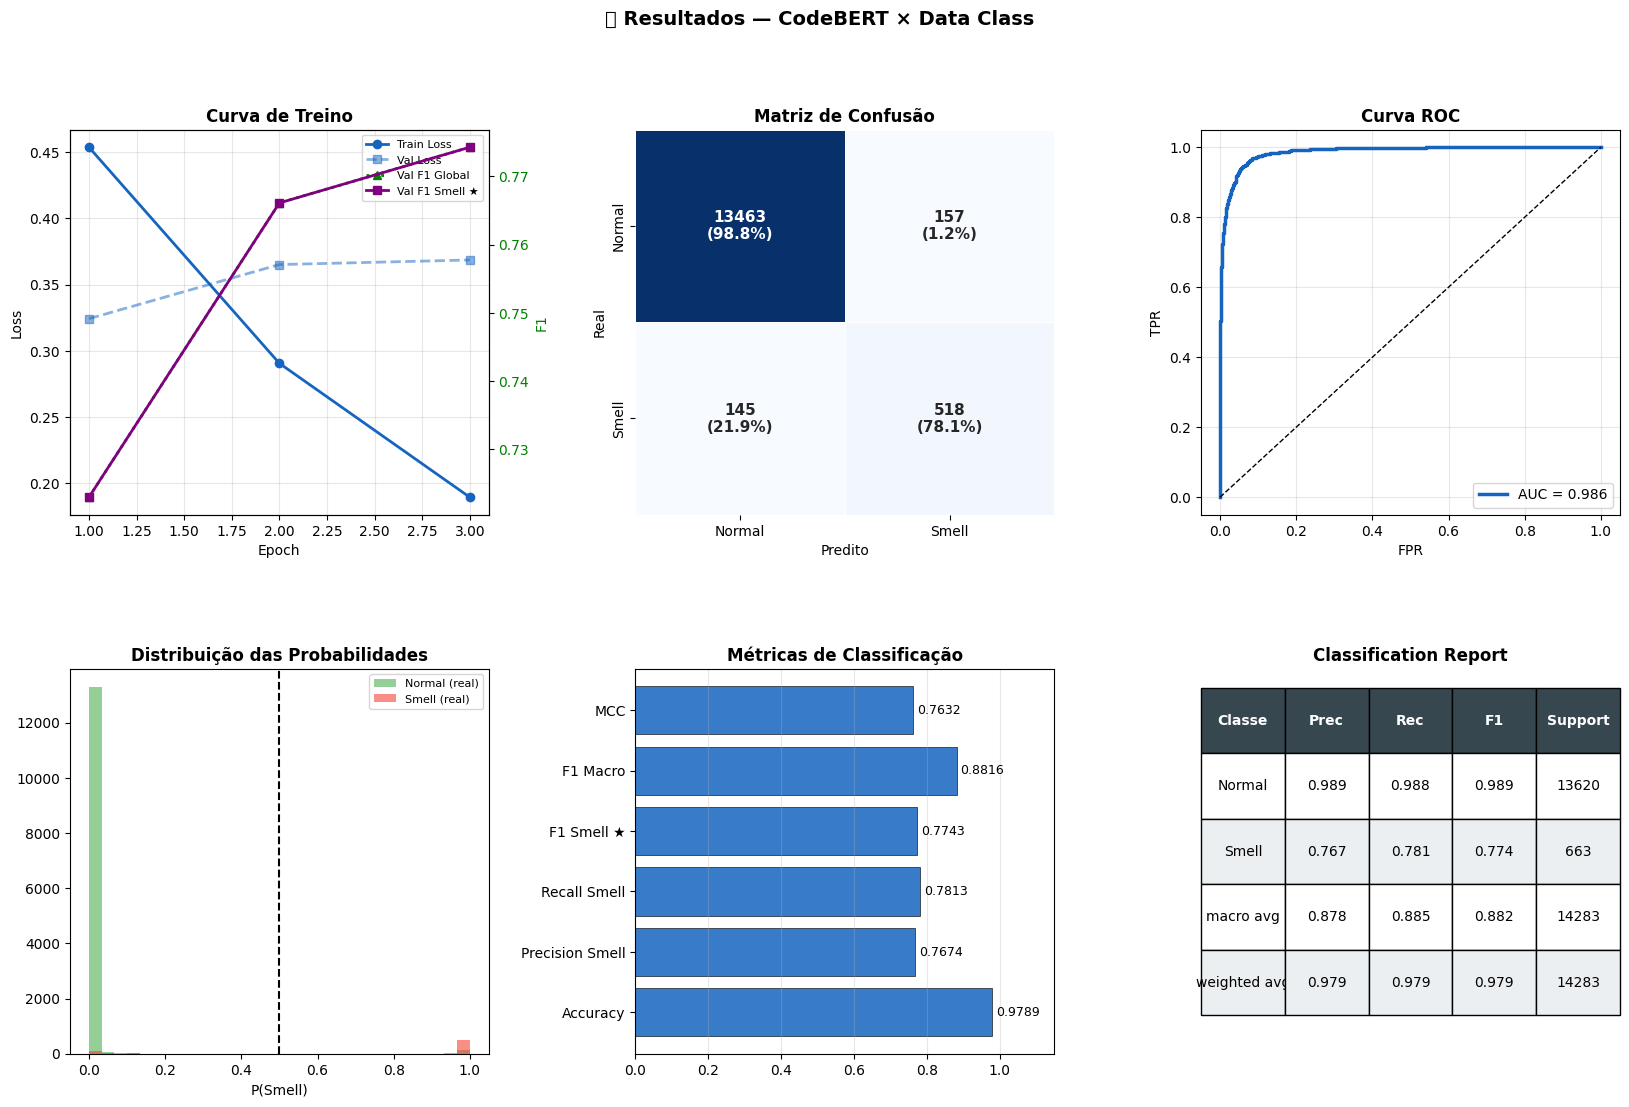

💾 Painel salvo em /kaggle/working/exp1_codebert_dataclass.png

📋 Classification Report completo — CodeBERT × Data Class
              precision    recall  f1-score   support

  Normal (0)       0.99      0.99      0.99     13620
   Smell (1)       0.77      0.78      0.77       663

    accuracy                           0.98     14283
   macro avg       0.88      0.88      0.88     14283
weighted avg       0.98      0.98      0.98     14283



In [7]:
lbl_cb_dc, pred_cb_dc, prob_cb_dc = evaluate_model(model_cb_dc, test_dl)

metrics_cb_dc = plot_experiment(
    history    = hist_cb_dc,
    y_true     = lbl_cb_dc,
    y_pred     = pred_cb_dc,
    y_prob     = prob_cb_dc,
    exp_label  = 'CodeBERT × Data Class',
    color      = EXP_COLORS['CodeBERT × Data Class'],
    save_path  = f"{CONFIG['output_dir']}exp1_codebert_dataclass.png",
)

print('\n📋 Classification Report completo — CodeBERT × Data Class')
print(classification_report(lbl_cb_dc, pred_cb_dc, target_names=['Normal (0)','Smell (1)']))

---
## 7. EXP-2 — CodeBERT × Feature Envy

In [8]:
print('═'*55)
print('  🔷 EXP-2 — CodeBERT × Feature Envy')
print('═'*55)

X_tr, X_te, y_tr, y_te = split_dataset(df_fe)

_nw = min(2 * N_GPUS, 4)
train_ds = CodeSmellDataset(X_tr, y_tr, tok_cb, CONFIG['max_length'])
test_ds  = CodeSmellDataset(X_te, y_te, tok_cb, CONFIG['max_length'])
train_dl = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
                      num_workers=_nw, pin_memory=True, persistent_workers=True)
test_dl  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False,
                      num_workers=_nw, pin_memory=True, persistent_workers=True)

model_cb_fe = RobertaForSequenceClassification.from_pretrained(
    CONFIG['codebert_name'], num_labels=CONFIG['num_labels'])

model_cb_fe, hist_cb_fe = train_model(model_cb_fe, train_dl, test_dl, 'CodeBERT×FeatureEnvy', y_tr)


═══════════════════════════════════════════════════════
  🔷 EXP-2 — CodeBERT × Feature Envy
═══════════════════════════════════════════════════════
   Treino: 26,692  (Normal=25,079 | Smell=1,613)
   Teste : 6,674  (Normal=6,271 | Smell=403)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  🖥️  Usando 2 GPUs com DataParallel
  ⚖️  Class weights: Normal=0.532 | Smell=8.274
  [CodeBERT×FeatureEnvy] Ep 1 | Step 100/1669 | Loss 0.6209
  [CodeBERT×FeatureEnvy] Ep 1 | Step 200/1669 | Loss 0.5865
  [CodeBERT×FeatureEnvy] Ep 1 | Step 300/1669 | Loss 0.6106
  [CodeBERT×FeatureEnvy] Ep 1 | Step 400/1669 | Loss 0.6435
  [CodeBERT×FeatureEnvy] Ep 1 | Step 500/1669 | Loss 0.6578
  [CodeBERT×FeatureEnvy] Ep 1 | Step 600/1669 | Loss 0.6597
  [CodeBERT×FeatureEnvy] Ep 1 | Step 700/1669 | Loss 0.6514
  [CodeBERT×FeatureEnvy] Ep 1 | Step 800/1669 | Loss 0.6558
  [CodeBERT×FeatureEnvy] Ep 1 | Step 900/1669 | Loss 0.6485
  [CodeBERT×FeatureEnvy] Ep 1 | Step 1000/1669 | Loss 0.6482
  [CodeBERT×FeatureEnvy] Ep 1 | Step 1100/1669 | Loss 0.6593
  [CodeBERT×FeatureEnvy] Ep 1 | Step 1200/1669 | Loss 0.6575
  [CodeBERT×FeatureEnvy] Ep 1 | Step 1300/1669 | Loss 0.6623
  [CodeBERT×FeatureEnvy] Ep 1 | Step 1400/1669 | Loss 0.6670
  [CodeBERT×FeatureEnvy] Ep 1 | Step 1500/1669 | Loss 0.6746
  [CodeBE

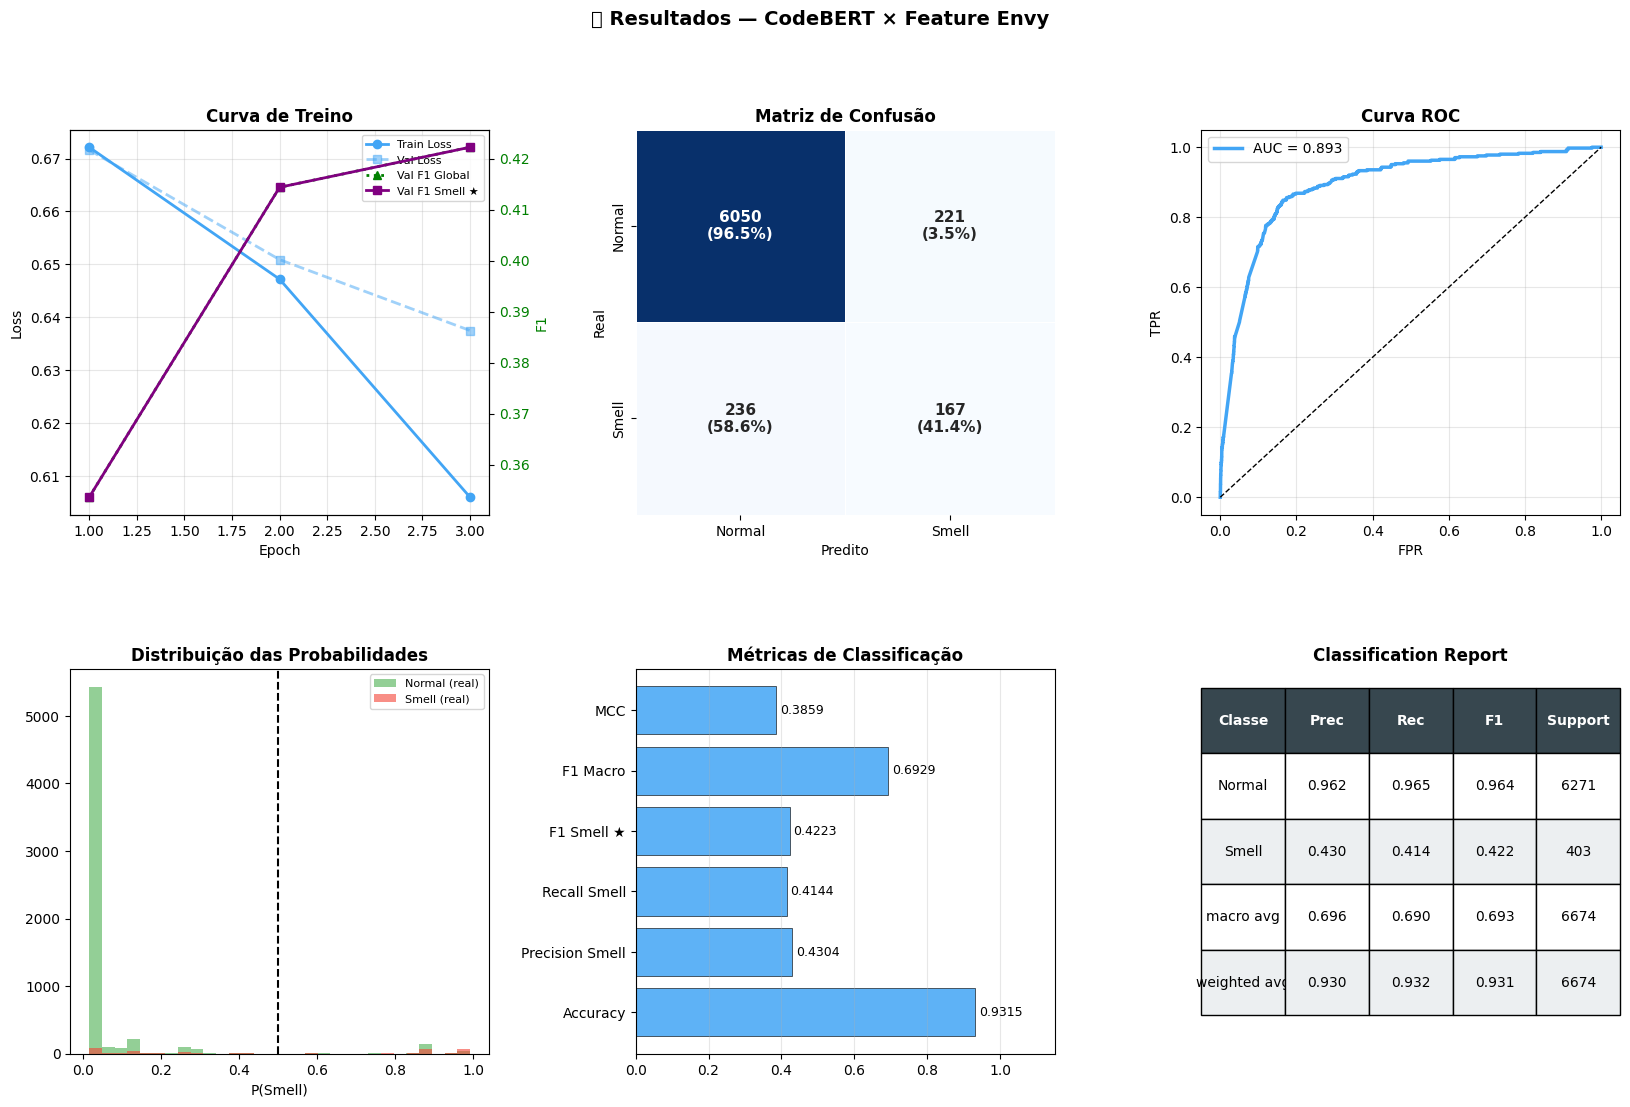

💾 Painel salvo em /kaggle/working/exp2_codebert_featureenvy.png

📋 Classification Report completo — CodeBERT × Feature Envy
              precision    recall  f1-score   support

  Normal (0)       0.96      0.96      0.96      6271
   Smell (1)       0.43      0.41      0.42       403

    accuracy                           0.93      6674
   macro avg       0.70      0.69      0.69      6674
weighted avg       0.93      0.93      0.93      6674



In [9]:
lbl_cb_fe, pred_cb_fe, prob_cb_fe = evaluate_model(model_cb_fe, test_dl)

metrics_cb_fe = plot_experiment(
    history    = hist_cb_fe,
    y_true     = lbl_cb_fe,
    y_pred     = pred_cb_fe,
    y_prob     = prob_cb_fe,
    exp_label  = 'CodeBERT × Feature Envy',
    color      = EXP_COLORS['CodeBERT × Feature Envy'],
    save_path  = f"{CONFIG['output_dir']}exp2_codebert_featureenvy.png",
)

print('\n📋 Classification Report completo — CodeBERT × Feature Envy')
print(classification_report(lbl_cb_fe, pred_cb_fe, target_names=['Normal (0)','Smell (1)']))

## 8. Salvamento do Modelo

In [ ]:
save_map = {
    'codebert_dataclass'   : (model_cb_dc, tok_cb),
    'codebert_featureenvy' : (model_cb_fe, tok_cb),
}

for folder_name, (model, tokenizer) in save_map.items():
    save_path = f"{CONFIG['output_dir']}{folder_name}"
    unwrap(model).save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f'  💾 Salvo: {save_path}')

# JSON com todas as métricas
metrics_cb_dc = compute_metrics(lbl_cb_dc, pred_cb_dc, prob_cb_dc)
metrics_cb_fe = compute_metrics(lbl_cb_fe, pred_cb_fe, prob_cb_fe)

all_results = {
    'CodeBERT × Data Class'   : {k: round(float(v), 6) for k, v in metrics_cb_dc.items()},
    'CodeBERT × Feature Envy' : {k: round(float(v), 6) for k, v in metrics_cb_fe.items()},
    'config'                  : {k: str(v) for k, v in CONFIG.items()},
}
json_path = f"{CONFIG['output_dir']}all_results.json"
with open(json_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f'\n  📄 Métricas JSON: {json_path}')
print('\n✅ Tudo salvo com sucesso!')


  💾 Salvo: /kaggle/working/codebert_dataclass
  💾 Salvo: /kaggle/working/codebert_featureenvy

  📄 Métricas JSON: /kaggle/working/all_results.json

✅ Tudo salvo com sucesso!
